In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [2]:
df['City'].unique()


<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str

In [3]:
bhopal = df[df['City'] == 'Bhopal'].copy()
print(f"Final rows after preprocessing: {len(bhopal)}")
bhopal.head()

Rows for Bhopal: 289


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
6303,Bhopal,2019-09-17,23.12,43.95,13.38,38.58,31.40,34.63,1.52,10.53,41.86,NaN,NaN,NaN,NaN,NaN
6304,Bhopal,2019-09-18,21.25,38.20,16.08,37.81,33.18,44.14,1.38,8.95,24.70,NaN,NaN,NaN,89.0,Satisfactory
6305,Bhopal,2019-09-19,16.94,41.09,12.94,25.28,23.96,47.43,0.95,8.08,31.66,NaN,NaN,NaN,77.0,Satisfactory
6306,Bhopal,2019-09-20,15.29,43.10,11.93,26.05,23.56,42.29,0.95,7.52,30.93,NaN,NaN,NaN,76.0,Satisfactory
6307,Bhopal,2019-09-21,20.75,62.70,14.90,30.90,28.55,46.25,1.41,7.31,27.19,NaN,NaN,NaN,82.0,Satisfactory


In [4]:
bhopal['Date'] = pd.to_datetime(bhopal['Date'])
bhopal = bhopal.sort_values('Date')
bhopal.isnull().sum()

City            0
Date            0
PM2.5           9
PM10            9
NO              9
NO2             9
NOx             9
NH3             9
CO              9
SO2             9
O3              9
Benzene       289
Toluene       289
Xylene        289
AQI            11
AQI_Bucket     11
dtype: int64

In [8]:
print(bhopal.columns.tolist())


['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI', 'AQI_Bucket']


In [9]:
import pandas as pd
bhopal['Date'] = pd.to_datetime(bhopal['Date'])
bhopal.sort_values('Date', inplace=True)
bhopal = bhopal.dropna(subset=['AQI'])
bhopal.ffill(inplace=True)
for lag in [1, 2, 3, 7]:
    bhopal[f'AQI_lag_{lag}'] = bhopal['AQI'].shift(lag)
bhopal.dropna(inplace=True)

print(f"Rows after cleaning: {len(bhopal)}")

Rows after cleaning: 271


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load data
df = pd.read_csv('../data/raw/city_day.csv')

# Filter Bhopal
bhopal = df[df['City'] == 'Bhopal'].copy()

# Prepare datetime and sort
bhopal['Date'] = pd.to_datetime(bhopal['Date'])
bhopal.sort_values('Date', inplace=True)

# Drop rows where AQI is missing (target)
bhopal = bhopal.dropna(subset=['AQI'])
print("After dropping missing AQI:", len(bhopal))

# Drop AQI_Bucket (not needed for regression, may cause NaNs)
bhopal.drop(columns=['AQI_Bucket'], inplace=True, errors='ignore')
print("Columns after dropping AQI_Bucket:", bhopal.columns.tolist())

# Forward fill numeric columns only
numeric_cols = bhopal.select_dtypes(include=['number']).columns
bhopal[numeric_cols] = bhopal[numeric_cols].ffill()
print("After forward fill numeric columns")

# Add temporal features
bhopal['day_of_week'] = bhopal['Date'].dt.dayofweek
bhopal['month'] = bhopal['Date'].dt.month
bhopal['is_weekend'] = (bhopal['day_of_week'] >= 5).astype(int)

# Create lag features for AQI
for lag in [1, 2, 3, 7]:
    bhopal[f'AQI_lag_{lag}'] = bhopal['AQI'].shift(lag)

# Check NaNs before dropping
print("\nNaN counts per column before dropping rows:")
print(bhopal.isnull().sum())

# Drop rows with any NaN
bhopal.dropna(inplace=True)
print("\nRows after dropping NaN:", len(bhopal))

if len(bhopal) > 0:
    # Define features and target
    exclude = ['Date', 'City', 'AQI']
    feature_cols = [c for c in bhopal.columns if c not in exclude]
    X = bhopal[feature_cols]
    y = bhopal['AQI']

    print("Features used:", feature_cols)
    print(f"X shape: {X.shape}, y shape: {y.shape}")

    # Split chronologically
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)
    print(f"Linear Regression - MAE: {mae_lr:.2f}, R²: {r2_lr:.2f}")

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)
    print(f"Random Forest - MAE: {mae_rf:.2f}, R²: {r2_rf:.2f}")

    # Plot Random Forest
    plt.figure(figsize=(12,5))
    plt.plot(y_test.values, label='Actual', alpha=0.7)
    plt.plot(y_pred_rf, label='Random Forest', alpha=0.7)
    plt.title('AQI Predictions – Bhopal (Random Forest)')
    plt.xlabel('Test sample')
    plt.ylabel('AQI')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No data left after cleaning. Check NaNs above.")

After dropping missing AQI: 278
Columns after dropping AQI_Bucket: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
After forward fill numeric columns

NaN counts per column before dropping rows:
City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene        278
Toluene        278
Xylene         278
AQI              0
day_of_week      0
month            0
is_weekend       0
AQI_lag_1        1
AQI_lag_2        2
AQI_lag_3        3
AQI_lag_7        7
dtype: int64

Rows after dropping NaN: 0
No data left after cleaning. Check NaNs above.


Rows after cleaning: 271
Features used: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'day_of_week', 'month', 'is_weekend', 'AQI_lag_1', 'AQI_lag_2', 'AQI_lag_3', 'AQI_lag_7']
X shape: (271, 16), y shape: (271,)
Train samples: 216, Test samples: 55
Linear Regression - MAE: 18.89, R²: -0.02
Random Forest - MAE: 8.59, R²: 0.74


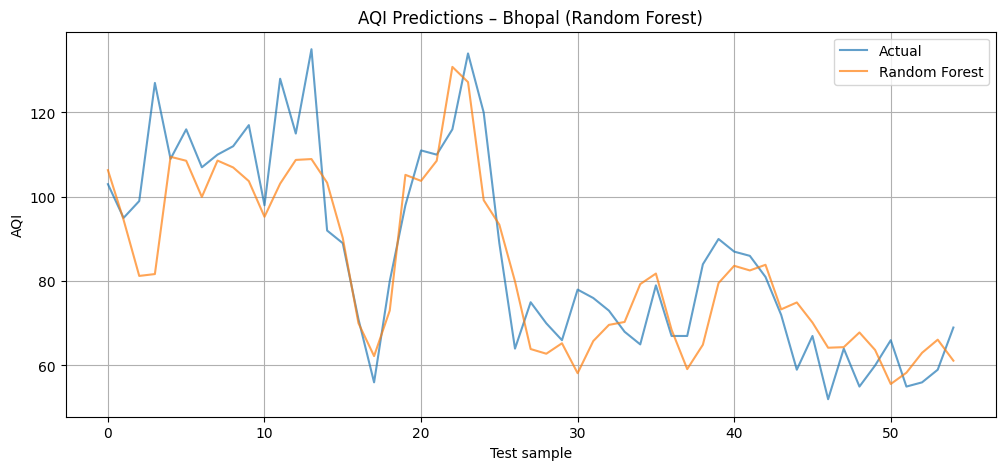

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load data
df = pd.read_csv('../data/raw/city_day.csv')

# Filter Bhopal
bhopal = df[df['City'] == 'Bhopal'].copy()

# Prepare datetime and sort
bhopal['Date'] = pd.to_datetime(bhopal['Date'])
bhopal.sort_values('Date', inplace=True)

# Drop rows where AQI is missing (target)
bhopal = bhopal.dropna(subset=['AQI'])

# Drop completely empty columns (Benzene, Toluene, Xylene)
bhopal.drop(columns=['Benzene', 'Toluene', 'Xylene', 'AQI_Bucket'], inplace=True, errors='ignore')

# Forward fill numeric columns (now only columns with some data)
numeric_cols = bhopal.select_dtypes(include=['number']).columns
bhopal[numeric_cols] = bhopal[numeric_cols].ffill()

# Add temporal features
bhopal['day_of_week'] = bhopal['Date'].dt.dayofweek
bhopal['month'] = bhopal['Date'].dt.month
bhopal['is_weekend'] = (bhopal['day_of_week'] >= 5).astype(int)

# Create lag features for AQI
for lag in [1, 2, 3, 7]:
    bhopal[f'AQI_lag_{lag}'] = bhopal['AQI'].shift(lag)

# Drop rows with any remaining NaN (from lags)
bhopal.dropna(inplace=True)

print(f"Rows after cleaning: {len(bhopal)}")

# Define features and target
exclude = ['Date', 'City', 'AQI']
feature_cols = [c for c in bhopal.columns if c not in exclude]
X = bhopal[feature_cols]
y = bhopal['AQI']

print("Features used:", feature_cols)
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Split chronologically
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression - MAE: {mae_lr:.2f}, R²: {r2_lr:.2f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MAE: {mae_rf:.2f}, R²: {r2_rf:.2f}")

# Plot Random Forest predictions
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(y_pred_rf, label='Random Forest', alpha=0.7)
plt.title('AQI Predictions – Bhopal (Random Forest)')
plt.xlabel('Test sample')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()